In [4]:
import pandas as pd

df = pd.read_csv("D:\DHV301\salary_survey_raw.csv")
print(f'Shape: {df.shape}')

Shape: (2800, 17)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   timestamp                        2800 non-null   str  
 1   how_old_are_you                  2800 non-null   str  
 2   industry                         2800 non-null   str  
 3   job_title                        2800 non-null   str  
 4   additional_context_on_job_title  1831 non-null   str  
 5   annual_salary                    2409 non-null   str  
 6   additional_monetary_comp         1262 non-null   str  
 7   currency                         2800 non-null   str  
 8   income_context                   531 non-null    str  
 9   country                          2685 non-null   str  
 10  us_state                         987 non-null    str  
 11  city                             1238 non-null   str  
 12  years_of_experience_in_field     2800 non-null   str  
 13 

In [6]:
## 1.1: Missing Values — không phải null nào cũng xử lý giống nhau
def missing_report(df):
    miss = df.isnull().sum()
    pct = (miss / len(df) * 100).round(2)
    return (pd.DataFrame({'count': miss, 'pct': pct})
              .query('count > 0').sort_values('pct', ascending=False))

print(missing_report(df))

                                 count    pct
income_context                    2269  81.04
us_state                          1813  64.75
city                              1562  55.79
additional_monetary_comp          1538  54.93
additional_context_on_job_title    969  34.61
race                               766  27.36
annual_salary                      391  13.96
country                            115   4.11
gender                              69   2.46


1. **income_context**: Drop -> tỷ lệ missing quá cao, ít giá trị thông tin
2. **us_state**: fillna('Unknown') -> missing nhiều, không quá quan trọng cho việc phân tích chính
3. **city**: fillna('Unknown') -> Tương tự us_state
4. **additional_monetary_comp**: fillna(0) -> giá trị tiền thưởng bổ sung, missing thường là Không có
5. **additional_context_on_job_title**: fillna('none') -> text-field, missing nghỉa là không cung cấp thêm
6. **race**: fillna('Prefer not to say') -> điền giá trị "không khai báo".
7. **annual_salary**: fillna(median)/Drop  -> Biến target quan trọng, xem xét drop cột hoặc MNAR.
8. **country**: fillna('Unknown') -> missng ít, không quá quan trọng cho phân tích chính
9. **gender**: fillna('Prefer not to say') -> missing rất ít, điền giá trị phổ biến hoặc "không khai báo".

In [7]:
df_missingclean = df.copy()

# Drop cột missing quá cao
df_missingclean = df_missingclean.drop(columns=['income_context'])

# Drop rows cho cột quan trọng
df_missingclean = df_missingclean.dropna(subset=['annual_salary'])

#fillna cho categorical/text
df_missingclean['us_state'] = df_missingclean['us_state'].fillna('Unknown')
df_missingclean['city'] = df_missingclean['city'].fillna('Unknown')
df_missingclean['country'] = df_missingclean['country'].fillna('Unknown')
df_missingclean['race'] = df_missingclean['race'].fillna('Prefer not to say')
df_missingclean['gender'] = df_missingclean['gender'].fillna('Prefer not to say')
df_missingclean['additional_context_on_job_title'] = df_missingclean['additional_context_on_job_title'].fillna('none')

#fillna
df_missingclean['additional_monetary_comp'] = df_missingclean['additional_monetary_comp'].fillna(0)

In [8]:
comparison = pd.DataFrame({
    'Before': missing_report(df)['count'],
    'After': missing_report(df_missingclean)['count']
}).fillna(0).astype(int)

print(comparison)

                                 Before  After
additional_context_on_job_title     969      0
additional_monetary_comp           1538      0
annual_salary                       391      0
city                               1562      0
country                             115      0
gender                               69      0
income_context                     2269      0
race                                766      0
us_state                           1813      0


**annual_salary**: MAR (Missing At Random) -> Mức lương thường bị missing khi người trả lời không muốn tiết lộ thu nhập (liên quan đến giá trị thu nhập cao/thấp hoặc ngành nghề). Không hoàn toàn ngẫu nhiên.

**income_context**: MNAR (Missing Not At Random) -> Tỷ lệ missing cực cao (81%). Cột này chỉ được điền khi có ngữ cảnh đặc biệt về thu nhập, nên missing mang ý nghĩa "không có thông tin bổ sung"

**gender**: MCAR (Missing Completely at Random) -> Tỷ lệ thấp và thường missing ngẫu nhiên do người dùng bỏ qua.

In [9]:
# 1.2: Duplicates — kiểm tra xong phải hỏi tại sao xuất hiện
# Kiểm tra duplicate toàn hàng
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup} ({n_dup/len(df)*100:.1f}%)')

Duplicate rows: 38 (1.4%)


In [10]:
key_columns = ['country', 'us_state', 'city', 'job_title', 'annual_salary', 'gender', 'race']
key_dup = df.duplicated(subset=key_columns).sum()
print(f'Duplicate rows theo key columns: {key_dup} ({key_dup/len(df)*100:.1f}%)')

Duplicate rows theo key columns: 79 (2.8%)


Dataset này có thể là khảo sát lương công nghệ, nên duplicate thường xảy ra vì:
- Người dùng submit nhiều lần: Nhiều người tham gia khảo sát gửi form nhiều lần (do nhầm, muốn sửa, hoặc test).
- Lỗi kỹ thuật khi thu thập dữ liệu: Form survey bị submit lại khi refresh trang hoặc network error.
- Join bảng sai: Nếu dataset được merge từ nhiều nguồn.

In [11]:
# Lưu số dòng trước khi xử lý
rows_before = len(df)

# Xử lý
df = df.drop_duplicates(subset=key_columns, keep='first')   # giữ lại bản ghi đầu tiên

rows_after = len(df)
duplicates_removed = rows_before - rows_after

print(f"Số dòng trước: {rows_before:,}")
print(f"Số dòng sau : {rows_after:,}")
print(f"Đã xóa: {duplicates_removed:,} dòng trùng ({(duplicates_removed/rows_before*100):.2f}%)")

Số dòng trước: 2,800
Số dòng sau : 2,721
Đã xóa: 79 dòng trùng (2.82%)


In [12]:
# 1.3: Data Types — dtype sai là nguồn gốc của 40% lỗi phân tích
print(df.dtypes) # Trước khi xử lý

timestamp                          str
how_old_are_you                    str
industry                           str
job_title                          str
additional_context_on_job_title    str
annual_salary                      str
additional_monetary_comp           str
currency                           str
income_context                     str
country                            str
us_state                           str
city                               str
years_of_experience_in_field       str
years_of_experience_overall        str
highest_level_of_education         str
gender                             str
race                               str
dtype: object


- timestamp: str -> datetime
- annual_salary, additional_monetary_comp: str -> float
- industry, job_title, currency, country, us_state, city, highest_level_of_education, gender, race: str -> category

In [14]:
df_dtypesclean = df.copy()

# Cột lương: object => float (xóa dấu phẩy và ký hiệu $)
for col in ['annual_salary', 'additional_monetary_comp']:
    if col in df_dtypesclean.columns:
        # Xóa ký tự không cần thiết
        df_dtypesclean[col] = df_dtypesclean[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
        # Chuyển sang numeric
        df_dtypesclean[col] = pd.to_numeric(df_dtypesclean[col], errors='coerce')

# Cột ngày: object => datetime
df_dtypesclean['timestamp'] = pd.to_datetime(df_dtypesclean['timestamp'], errors='coerce')

# Cột category: object => category (tiết kiệm bộ nhớ)
df_dtypesclean['industry'] = df_dtypesclean['industry'].astype('category')
df_dtypesclean['job_title'] = df_dtypesclean['job_title'].astype('category')
df_dtypesclean['currency'] = df_dtypesclean['currency'].astype('category')
df_dtypesclean['country'] = df_dtypesclean['country'].astype('category')
df_dtypesclean['us_state'] = df_dtypesclean['us_state'].astype('category')
df_dtypesclean['city'] = df_dtypesclean['city'].astype('category')
df_dtypesclean['highest_level_of_education'] = df_dtypesclean['highest_level_of_education'].astype('category')
df_dtypesclean['gender'] = df_dtypesclean['gender'].astype('category')
df_dtypesclean['race'] = df_dtypesclean['race'].astype('category')

# Kiểm tra sau khi convert
df_dtypesclean.dtypes # phải thấy float64, datetime64, category

timestamp                          datetime64[us]
how_old_are_you                               str
industry                                 category
job_title                                category
additional_context_on_job_title               str
annual_salary                             float64
additional_monetary_comp                  float64
currency                                 category
income_context                                str
country                                  category
us_state                                 category
city                                     category
years_of_experience_in_field                  str
years_of_experience_overall                   str
highest_level_of_education               category
gender                                   category
race                                     category
dtype: object

Dtypes sai sẽ xảy ra lỗi  trong phân tích vì:
- Numeric lưu dưới dạng string:
  + Không tính được mean, median, sum, correlation
  + Không vẽ được histogram, boxplot đúng
  + Tốn rất nhiều bộ nhớ
- Datetime lưu dạng object: Không lọc được theo thời gian, không resample
- Categorical lưu dạng object: Tốn bộ nhớ cực lớn, chậm khi groupby, merge, pivot_table.

In [15]:
memory_before = df.memory_usage(deep=True).sum() / 1024**2
memory_after  = df_dtypesclean.memory_usage(deep=True).sum() / 1024**2

print(f"Bộ nhớ trước convert : {memory_before:.2f} MB")
print(f"Bộ nhớ sau convert  : {memory_after:.2f} MB")
print(f"Tiết kiệm được       : {memory_before - memory_after:.2f} MB")
print(f"Tỷ lệ tiết kiệm      : {((memory_before - memory_after)/memory_before*100):.1f}%")

Bộ nhớ trước convert : 2.69 MB
Bộ nhớ sau convert  : 0.90 MB
Tiết kiệm được       : 1.80 MB
Tỷ lệ tiết kiệm      : 66.7%


In [16]:
# 2.1: Outliers — phát hiện đúng còn quan trọng hơn xử lý
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_clean = df_dtypesclean.copy()

# Phương pháp 1: IQR — tốt cho dữ liệu lệch phải
def detect_outliers_iqr(data, col):
    Q1, Q3 = data[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    
    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"\n=== Outliers theo IQR - {col} ===")
    print(f"Lower bound: {lower:,.2f} | Upper bound: {upper:,.2f}")
    print(f"Số outliers: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
    return outliers, lower, upper

outliers_salary, lb_sal, ub_sal = detect_outliers_iqr(df_clean, 'annual_salary')
outliers_comp, lb_comp, ub_comp = detect_outliers_iqr(df_clean, 'additional_monetary_comp')


=== Outliers theo IQR - annual_salary ===
Lower bound: -25,423.38 | Upper bound: 189,927.62
Số outliers: 110 (4.04%)

=== Outliers theo IQR - additional_monetary_comp ===
Lower bound: -10,814.00 | Upper bound: 21,994.00
Số outliers: 62 (2.28%)


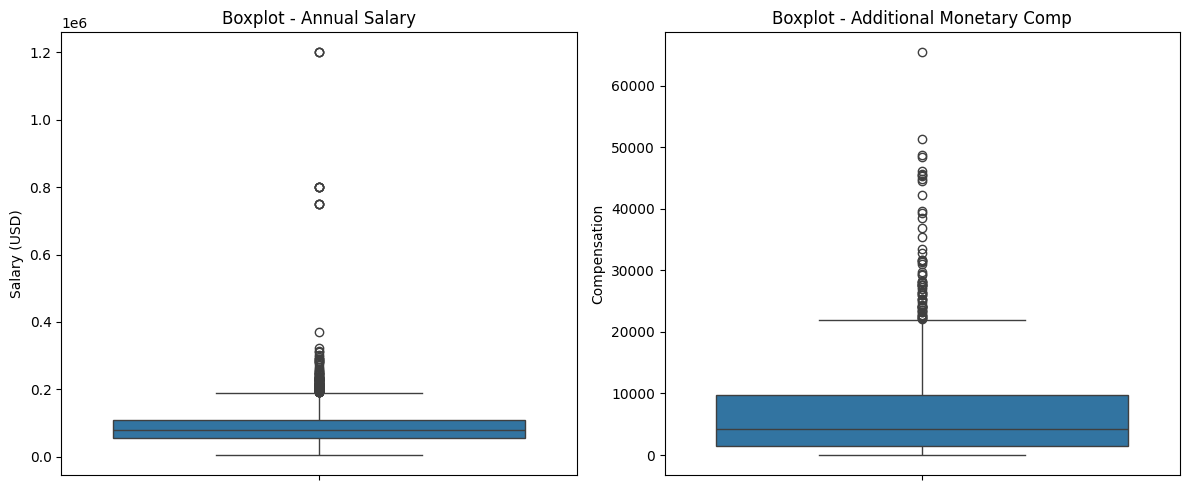

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean['annual_salary'])
plt.title('Boxplot - Annual Salary')
plt.ylabel('Salary (USD)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['additional_monetary_comp'])
plt.title('Boxplot - Additional Monetary Comp')
plt.ylabel('Compensation')

plt.tight_layout()
plt.show()

In [107]:
# Phương pháp 2: Z-score — tốt cho phân phối chuẩn
def detect_outliers_zscore(data, col, thresh=3):
    mean = data[col].mean()
    std = data[col].std()
    z = (data[col] - mean) / std
    outliers = data[z.abs() > thresh]
    n_outliers = len(outliers)
    pct = n_outliers / len(data) * 100
    print(f"\n=== Outliers theo Z-score (thresh={thresh}) - {col} ===")
    print(f"Mean: {mean:,.2f} | Std: {std:,.2f}")
    print(f"Số outliers: {n_outliers} ({pct:.2f}%)")
    return outliers, mean, std

outliers_z_salary, mean_sal, std_sal = detect_outliers_zscore(df_clean, 'annual_salary', thresh=3)
outliers_z_comp, mean_comp, std_comp = detect_outliers_zscore(df_clean, 'additional_monetary_comp', thresh=3)


=== Outliers theo Z-score (thresh=3) - annual_salary ===
Mean: 91,295.07 | Std: 75,048.18
Số outliers: 14 (0.51%)

=== Outliers theo Z-score (thresh=3) - additional_monetary_comp ===
Mean: 6,986.14 | Std: 8,059.19
Số outliers: 22 (0.81%)


- Outliers theo IQR của annual_salary is cao hơn outliers theo Z-score của annual_salary (110 > 14)
  ->Phù hợp dữ liệu lệch phải: tốt hơn
- Outliers theo IQR của additional_monetary_comp is cao hơn outliers theo Z-score của additional_monetary_comp (62 > 22)
  ->Phù hợp dữ liệu lệch phải: giả định chuẩn

- Outliers hợp lệ nhưng hiếm, ví dụ: CEO thường có lương rất cao.

Áp dụng chiến lược Winsorization(Giới hạn/Cắt cụm):
chiến lược này thay thế các giá trị quá lớn hoặc quá nhỏ bằng các giá trị cận biên tại các phân vị xác định
- Bảo toàn kích thước mẫu: Không làm mất mát thông tin quan trọng do xóa hàng dữ liệu.
- Giảm nhiễu: Hạn chế tối đa việc các điểm cực trị làm sai lệch kết quả mô hình hoặc các phép đo thống kê (như giá trị trung bình).
- Tính ổn định: Tránh được các lỗi vặn vẹo phân phối dữ liệu (skewness) mạnh tay

In [21]:
# 2.2: Chuẩn hóa chuỗi — kỹ năng thực tế quan trọng nhất
pipeline_text = ['industry', 'job_title', 'currency', 'country', 'us_state', 'city', 'highest_level_of_education', 'gender', 'race']
df_dtypesclean[pipeline_text] = df_dtypesclean[pipeline_text].apply(
    lambda col: col.str.lower() # bước 1: lowercase trước
                   .str.strip() # bước 2: bỏ khoảng trắng
                   .str.replace(r'\s+', ' ', regex=True) # khoảng trắng đơn

                   .str.replace(r'[^a-z0-9 ]', '', regex=True) # bỏ ký tự đặc biệt
)

df_dtypesclean[pipeline_text].value_counts().head(10)

industry             job_title             currency  country        us_state       city           highest_level_of_education  gender                 race                             
nonprofit            outreach coordinator  gbp       united states  colorado       boston         college degree              woman                  asian or asian american              1
education higher ed  lecturer              usd       us             oregon         chicago        college degree              male                   hispanic latino or spanish origin    1
consulting           strategy consultant   usd       united states  massachusetts  austin         college degree              woman                  black or african american            1
bankingfinance       compliance officer    gbp       united states  oregon         seattle        college degree              female                 asian or asian american              1
hrpeople ops         hr business partner   usd       united state

Chuẩn hóa trước khi phân tích để đảm bảo độ chính xác, giúp thuật toán học máy hội tụ nhanh hơn, loại bỏ các kết quả bị sai lệch do sự chênh lệch thang đo và giúp người phân tích đưa ra quyết định đúng đắn.

In [120]:
# 2.3: Normalization — khi nào dùng, khi nào không cần
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df_scaled = df_dtypesclean.copy()

# LÝ DO chọn Min-Max: cột annual_salary này không phân phối chuẩn
# và muốn giữ khoảng [0, 1] để dễ so sánh
minmax_scaler = MinMaxScaler()
df_scaled['annual_salary'] = minmax_scaler.fit_transform(df_scaled[['annual_salary']])

print(f"Giá trị min sau scaling: {df_scaled['annual_salary'].min():.4f}")
print(f"Giá trị max sau scaling: {df_scaled['annual_salary'].max():.4f}")

Giá trị min sau scaling: 0.0000
Giá trị max sau scaling: 1.0000


In [122]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

standard_scaler = StandardScaler()
df_scaled['additional_monetary_comp'] = standard_scaler.fit_transform(df_scaled[['additional_monetary_comp']])
print(f"Mean sau scaling: {df_scaled['additional_monetary_comp'].mean():.6f} (gần 0)")
print(f"Std sau scaling: {df_scaled['additional_monetary_comp'].std():.6f} (gần 1)")

Mean sau scaling: -0.000000 (gần 0)
Std sau scaling: 1.000440 (gần 1)


KHÔNG cần normalize (chuẩn hóa) khi: dữ liệu đã có sẵn thang đo nhỏ, dùng các thuật toán dựa trên cây, chứa nhiều điểm dữ liệu dị biệt (outliers), hoặc khi giải quyết bài toán xử lý ngôn ngữ tự nhiên/ảnh

In [124]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
df_scaled['annual_salary'] = robust_scaler.fit_transform(df_scaled[['annual_salary']])
print(f"   Median sau scaling: {df_scaled['annual_salary'].median():.6f} (gần 0)")
print(f"   IQR sau scaling: {df_scaled['annual_salary'].quantile(0.75) - df_scaled['annual_salary'].quantile(0.25):.6f} (gần 1)")
print(f"   Min sau scaling: {df_scaled['annual_salary'].min():.4f}")
print(f"   Max sau scaling: {df_scaled['annual_salary'].max():.4f}")

   Median sau scaling: 0.000000 (gần 0)
   IQR sau scaling: 1.000000 (gần 1)
   Min sau scaling: -1.3694
   Max sau scaling: 20.8270


RobustScaler TỐT HƠN StandardScaler khi:
- Dữ liệu có nhiều outlier
- Dữ liệu phân phối lệch phải (skewed right)
- Không muốn xóa outlier nhưng vẫn cần chuẩn hóa
- Dùng cho PCA, t-SNE, clustering với dữ liệu skew

In [ ]:
#3.1: Encoding Categorical Variables — chọn đúng kỹ thuật


Áp dụng OHE (One-Hot Encoding) cho cột có 100 giá trị unique là vấn đề vì nó tạo ra tới 100 cột mới chỉ toàn chứa số 0 và số 1. Việc này dẫn đến:
- "Lời nguyền" chiều dữ liệu (Curse of Dimensionality): Số lượng cột tăng đột ngột làm mô hình cồng kềnh, dễ bị overfitting (học vẹt).
- Lãng phí bộ nhớ (Sparsity): Dữ liệu trở nên thưa thớt vì chứa quá nhiều số 0, làm chậm thời gian huấn luyện

In [ ]:
# 3.2: Feature Engineering — tạo biến mới có ý nghĩa

In [2]:
# 3.3: Viết Pipeline hoàn chỉnh — hàm tái sử dụng được
def clean_data(df):
    """
    Pipeline làm sạch Salary Survey dataset.
    
    Parameters: df (DataFrame) — raw data
    Returns: df_clean (DataFrame) — đã xử lý
    
    Các bước xử lý:
      1. Xóa duplicate
      2. Convert dtype (salary, timestamp)
      3. Xử lý missing values theo chiến lược từng cột
      4. Chuẩn hóa chuỗi: job_title, industry
      5. Xử lý outlier cột salary
      6. Encode categorical columns
      7. Tạo feature mới
    """
    df = df.copy() # không sửa in-place
    # Bước 1: Duplicate
    df = df.drop_duplicates().reset_index(drop=True)
    # Bước 2: Convert dtype
    df['annual_salary'] = pd.to_numeric(
    df['annual_salary'].str.replace(',', ''), errors='coerce')
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    # Bước 3: Missing values (xem quyết định trong Data Quality Report)
    df['age'].fillna(df['age'].median(), inplace=True)
    df['country'].fillna('Unknown', inplace=True)
    # Bước 4: Chuẩn hóa chuỗi: job_title, industry
    df['job_title'] = (df['job_title'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True))
    df['industry'] = (df['industry'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True))
    # Bước 5: Xử lý outlier cột salary (dùng IQR method)
    Q1 = df['annual_salary'].quantile(0.25)
    Q3 = df['annual_salary'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Cap outliers thay vì xóa (phù hợp với salary data)
    df['annual_salary'] = df['annual_salary'].clip(lower=lower_bound, upper=upper_bound)
    # Bước 6: Encode categorical columns(One-hot encoding cho các cột chính)
    categorical_cols = ['country', 'industry']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
    # Bước 7: Tạo feature mới (job_tilte feauture)
    df['job_title_length'] = df['job_title'].str.len()
    df['is_senior'] = df['job_title'].str.contains('senior|lead|principal|head|chief', regex=True).astype(int)
    df['is_manager'] = df['job_title'].str.contains('manager|director|vp|cto|cfo', regex=True).astype(int)
    
    return df
    
df_clean = clean_data(df)

NameError: name 'df' is not defined